# Experiment 1

As the dataset is a tabular data, I'm going to try bunch of experimetns using MLP

In [21]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

## Import data

Make train and test features and labels dataframes

In [22]:
DATA_DIR = "../data"

# --------------  Train Features and Labels ------------------
main_dataset = pd.read_csv(f"{DATA_DIR}/train_features.csv")
main_dataset.set_index("sig_id", inplace=True)  # set sig_id as index

# filter out control samples
main_dataset = main_dataset[main_dataset["cp_type"] == "trt_cp"]
main_dataset["cp_dose_bin"] = main_dataset["cp_dose"].map({"D1": 0, "D2": 1})  # make cp_dose a binary variable

# make metadata dataframe
metadata_cols = ["cp_type", "cp_time", "cp_dose"]
main_metadata = main_dataset[metadata_cols].copy()
# train_metadata_df.set_index("sig_id", inplace=True)  # set sig_id as index

# make train_features dataframe
feature_cols = [col for col in main_dataset.columns if col not in metadata_cols and col != "sig_id"]
main_features_df = main_dataset[feature_cols].copy()


# Make train_targets dataframe
main_targets_df = pd.read_csv(f"{DATA_DIR}/train_targets_scored.csv")
main_targets_df.set_index("sig_id", inplace=True)  # set sig_id as index

In [23]:
DATA_DIR = "../data"

# --------------  Train Features and Labels ------------------
main_dataset = pd.read_csv(f"{DATA_DIR}/train_features.csv")
main_dataset.set_index("sig_id", inplace=True)  # set sig_id as index

# filter out control samples
main_dataset = main_dataset[main_dataset["cp_type"] == "trt_cp"]
main_dataset["cp_dose_bin"] = main_dataset["cp_dose"].map({"D1": 0, "D2": 1})  # make cp_dose a binary variable

# make metadata dataframe
metadata_cols = ["cp_type", "cp_time", "cp_dose"]
main_metadata = main_dataset[metadata_cols].copy()
# train_metadata_df.set_index("sig_id", inplace=True)  # set sig_id as index

# make train_features dataframe
feature_cols = [col for col in main_dataset.columns if col not in metadata_cols and col != "sig_id"]
main_features_df = main_dataset[feature_cols].copy()


# Make train_targets dataframe
main_targets_df = pd.read_csv(f"{DATA_DIR}/train_targets_scored.csv")
main_targets_df.set_index("sig_id", inplace=True)  # set sig_id as index

# -------------- Test Features and Labels -----------------
# Make test_features dataframe
test_features_df = pd.read_csv(f"{DATA_DIR}/test_features.csv")
test_features_df.set_index("sig_id", inplace=True)  # set sig_id as index

# filter out control samples
test_features_df["cp_dose_bin"] = test_features_df["cp_dose"].map({"D1": 0, "D2": 1})  # make cp_dose a binary variable

# Make test_metadata dataframe
test_metadata_df = test_features_df[metadata_cols].copy()

# make test_features dataframe
test_features_df = test_features_df[feature_cols].copy()

## 5-Fold Cross-Validation Setup

Drug-level `MultilabelStratifiedKFold` (5 folds) ensures no drug leaks across train/val splits. Each fold trains on 4 folds and validates on 1. OOF (out-of-fold) predictions cover every sample exactly once for a final unbiased evaluation.

In [24]:
# 1. Load the drug mapping (Risk A Fix)
train_drug = pd.read_csv(f"{DATA_DIR}/train_drug.csv")

# 2. Merge targets with drug_id
# We need to know which MoAs each drug_id triggers
targets_with_drug = main_targets_df.merge(train_drug, on='sig_id')

# 3. Create a drug-level target dataframe
# A drug is considered 'positive' for an MoA if any of its experiments are positive
drug_targets = targets_with_drug.groupby('drug_id').max().reset_index()

# 4. Perform Stratified K-Fold on the DRUGS
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
drug_targets['fold'] = -1

# X is just drug_id, y is the 206 targets at the drug level
X_drugs = drug_targets['drug_id']
y_drugs = drug_targets.drop(['drug_id', 'sig_id'], axis=1)

for fold, (train_idx, val_idx) in enumerate(mskf.split(X_drugs, y_drugs)):
    drug_targets.loc[val_idx, 'fold'] = fold

# 5. Map these folds back to the original sig_ids
drug_to_fold = dict(zip(drug_targets['drug_id'], drug_targets['fold']))
sig_to_fold = train_drug.set_index('sig_id')['drug_id'].map(drug_to_fold)
main_dataset['fold'] = sig_to_fold

## PyTorch Dataset and DataLoaders

In [25]:
class MoADataset(Dataset):
    def __init__(self, features, targets=None):
        self.X = torch.tensor(features.values, dtype=torch.float32)
        self.y = torch.tensor(targets.values, dtype=torch.float32) if targets is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

## Pytorch Model

In [26]:
import torch.nn as nn

class MoAModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        # Layer 1
        self.fc1 = nn.Linear(input_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.dropout1 = nn.Dropout(0.4)
        
        # Layer 2
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.dropout2 = nn.Dropout(0.4)
        
        # Output Layer
        self.fc3 = nn.Linear(256, output_dim)
        # NO SIGMOID HERE!
    
    def forward(self, x):
        # Block 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout2(x)
        
        # Output
        x = self.fc3(x)
        return x

## Train Model

Define the hyper-parameters

In [27]:
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

INPUT_DIM  = main_features_df.shape[1]
OUTPUT_DIM = main_targets_df.shape[1]
BATCH_SIZE = 128
N_EPOCHS   = 50
N_FOLDS    = 5

print(f"Device: {device} | Input dim: {INPUT_DIM} | Output dim: {OUTPUT_DIM}")

Device: cuda | Input dim: 873 | Output dim: 206


In [28]:
fold_train_losses  = {}
fold_val_losses    = {}
fold_train_f1s     = {}
fold_val_f1s       = {}
fold_best_val_loss = {}

# OOF arrays — filled one fold at a time
oof_preds   = np.zeros((len(main_features_df), OUTPUT_DIM))
oof_targets = np.zeros((len(main_features_df), OUTPUT_DIM))

for fold_id in range(N_FOLDS):
    print(f"\n{'='*55}\nFold {fold_id + 1} / {N_FOLDS}\n{'='*55}")

    val_mask   = main_dataset['fold'] == fold_id
    train_mask = ~val_mask

    X_train_f = main_features_df[train_mask]
    y_train_f = main_targets_df.loc[X_train_f.index]
    X_val_f   = main_features_df[val_mask]
    y_val_f   = main_targets_df.loc[X_val_f.index]

    train_loader = DataLoader(MoADataset(X_train_f, y_train_f), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(MoADataset(X_val_f,   y_val_f),   batch_size=BATCH_SIZE, shuffle=False)

    model     = MoAModel(input_dim=INPUT_DIM, output_dim=OUTPUT_DIM).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    train_losses, val_losses = [], []
    train_f1s,   val_f1s    = [], []
    best_val_loss = float('inf')

    for epoch in range(N_EPOCHS):
        # ---- Train ----
        model.train()
        epoch_train_loss = 0.0
        all_train_preds, all_train_targets = [], []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * len(X_batch)
            all_train_preds.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_train_targets.append(y_batch.cpu().numpy())

        epoch_train_loss /= len(X_train_f)
        train_f1 = f1_score(np.vstack(all_train_targets),
                            (np.vstack(all_train_preds) > 0.5).astype(int),
                            average='macro', zero_division=0)

        # ---- Validate ----
        model.eval()
        epoch_val_loss = 0.0
        all_val_preds, all_val_targets_ep = [], []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                epoch_val_loss += criterion(logits, y_batch).item() * len(X_batch)
                all_val_preds.append(torch.sigmoid(logits).cpu().numpy())
                all_val_targets_ep.append(y_batch.cpu().numpy())

        epoch_val_loss /= len(X_val_f)
        val_f1 = f1_score(np.vstack(all_val_targets_ep),
                          (np.vstack(all_val_preds) > 0.5).astype(int),
                          average='macro', zero_division=0)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), f"best_model_fold{fold_id}.pth")

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{N_EPOCHS} | "
                  f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
                  f"Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")

    fold_train_losses[fold_id]  = train_losses
    fold_val_losses[fold_id]    = val_losses
    fold_train_f1s[fold_id]     = train_f1s
    fold_val_f1s[fold_id]       = val_f1s
    fold_best_val_loss[fold_id] = best_val_loss

    # Collect OOF predictions using the best checkpoint
    best_model_f = MoAModel(input_dim=INPUT_DIM, output_dim=OUTPUT_DIM).to(device)
    best_model_f.load_state_dict(torch.load(f"best_model_fold{fold_id}.pth", map_location=device))
    best_model_f.eval()

    fold_preds = []
    with torch.no_grad():
        for X_batch, _ in val_loader:
            fold_preds.append(torch.sigmoid(best_model_f(X_batch.to(device))).cpu().numpy())

    val_indices = np.where(val_mask.values)[0]
    oof_preds[val_indices]   = np.vstack(fold_preds)
    oof_targets[val_indices] = y_val_f.values

    print(f"  → Best Val Loss: {best_val_loss:.4f} | Best Val F1: {max(val_f1s):.4f}")

mean_val_loss = np.mean(list(fold_best_val_loss.values()))
mean_val_f1   = np.mean([max(fold_val_f1s[i]) for i in range(N_FOLDS)])
print(f"\n{'='*55}")
print(f"CV complete | Mean Best Val Loss: {mean_val_loss:.4f} | Mean Best Val F1: {mean_val_f1:.4f}")


Fold 1 / 5
  Epoch  10/50 | Train Loss: 0.0157 | Val Loss: 0.0203 | Train F1: 0.0680 | Val F1: 0.0478
  Epoch  20/50 | Train Loss: 0.0124 | Val Loss: 0.0203 | Train F1: 0.1362 | Val F1: 0.0679
  Epoch  30/50 | Train Loss: 0.0090 | Val Loss: 0.0228 | Train F1: 0.2649 | Val F1: 0.0715
  Epoch  40/50 | Train Loss: 0.0062 | Val Loss: 0.0260 | Train F1: 0.4472 | Val F1: 0.0741
  Epoch  50/50 | Train Loss: 0.0046 | Val Loss: 0.0295 | Train F1: 0.6207 | Val F1: 0.0789
  → Best Val Loss: 0.0199 | Best Val F1: 0.0800

Fold 2 / 5
  Epoch  10/50 | Train Loss: 0.0158 | Val Loss: 0.0189 | Train F1: 0.0699 | Val F1: 0.0413
  Epoch  20/50 | Train Loss: 0.0124 | Val Loss: 0.0196 | Train F1: 0.1389 | Val F1: 0.0599
  Epoch  30/50 | Train Loss: 0.0091 | Val Loss: 0.0215 | Train F1: 0.2667 | Val F1: 0.0737
  Epoch  40/50 | Train Loss: 0.0063 | Val Loss: 0.0244 | Train F1: 0.4543 | Val F1: 0.0693
  Epoch  50/50 | Train Loss: 0.0047 | Val Loss: 0.0282 | Train F1: 0.6221 | Val F1: 0.0697
  → Best Val Loss:

## Training Curves per Fold

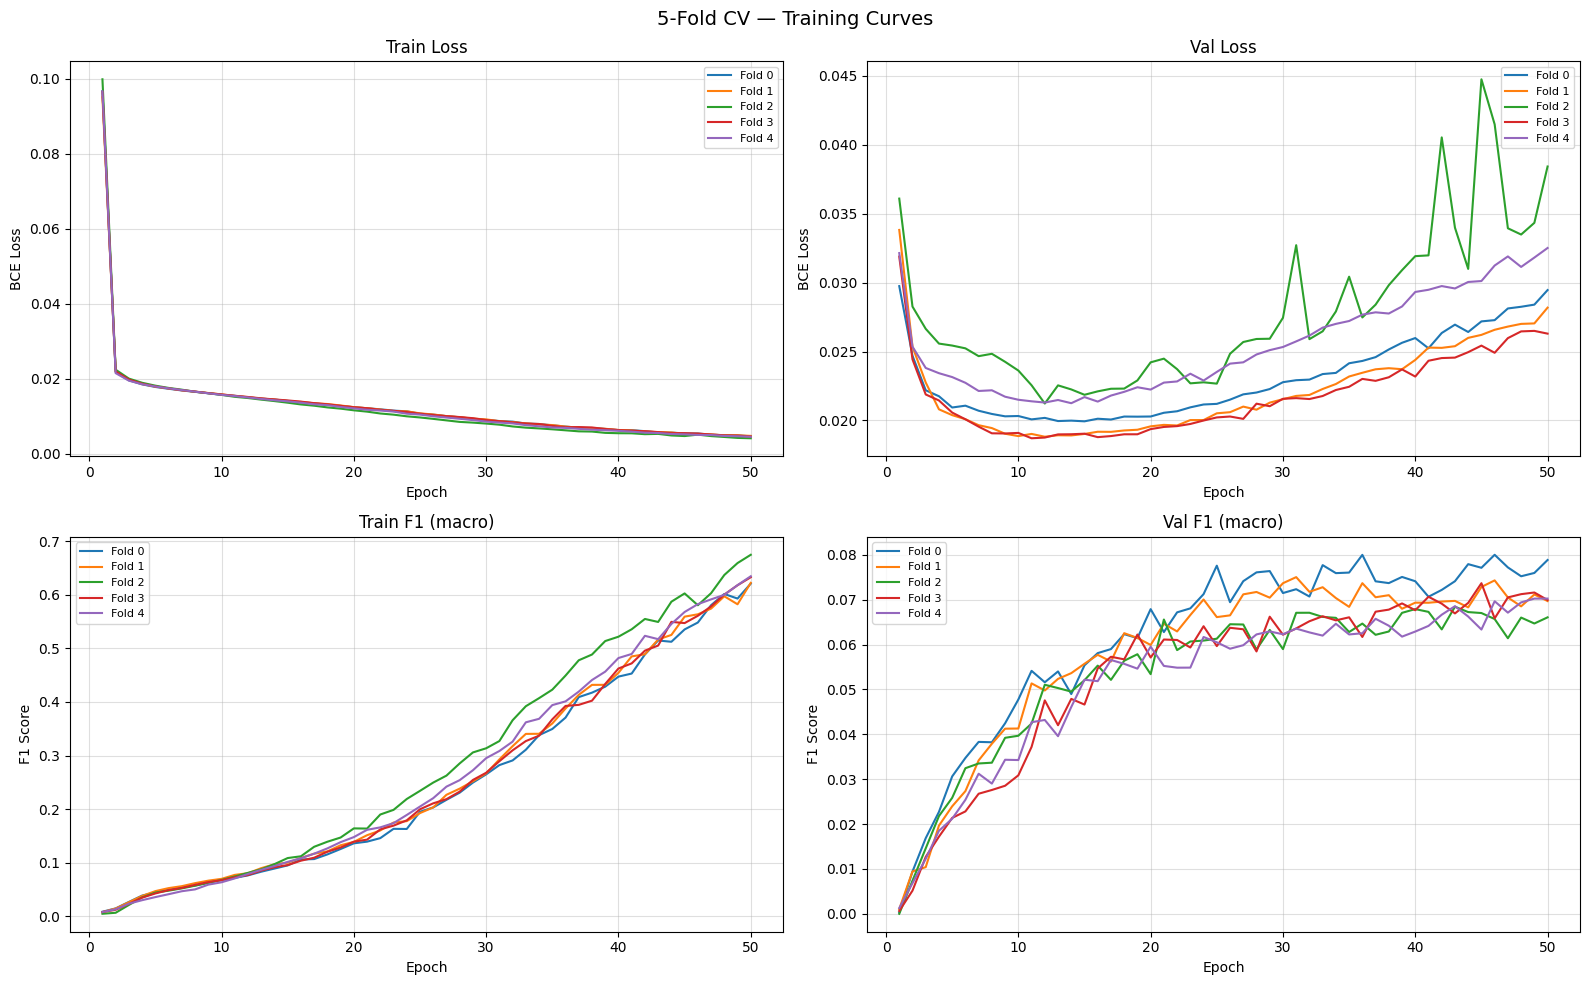

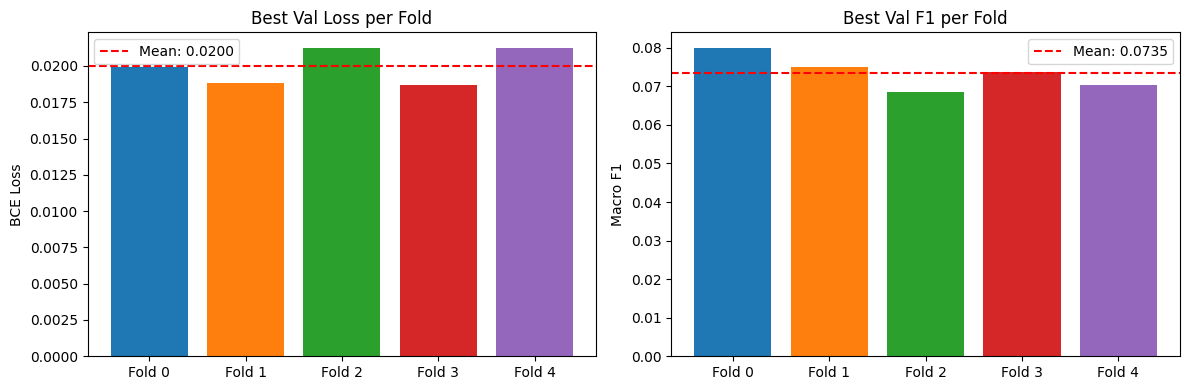

In [29]:
epochs = range(1, N_EPOCHS + 1)
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
titles  = ['Train Loss', 'Val Loss', 'Train F1 (macro)', 'Val F1 (macro)']
ylabels = ['BCE Loss',   'BCE Loss', 'F1 Score',          'F1 Score']
data_keys = [fold_train_losses, fold_val_losses, fold_train_f1s, fold_val_f1s]

for ax, title, ylabel, data in zip(axes.ravel(), titles, ylabels, data_keys):
    for fold_id in range(N_FOLDS):
        ax.plot(epochs, data[fold_id], color=colors[fold_id], label=f'Fold {fold_id}')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('5-Fold CV — Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

# ---- Summary bar charts ----
best_val_losses_list = [fold_best_val_loss[i] for i in range(N_FOLDS)]
best_val_f1s_list    = [max(fold_val_f1s[i])  for i in range(N_FOLDS)]
fold_labels          = [f'Fold {i}' for i in range(N_FOLDS)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(fold_labels, best_val_losses_list, color=colors[:N_FOLDS])
axes[0].axhline(np.mean(best_val_losses_list), color='red', linestyle='--',
                label=f'Mean: {np.mean(best_val_losses_list):.4f}')
axes[0].set_title('Best Val Loss per Fold')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].bar(fold_labels, best_val_f1s_list, color=colors[:N_FOLDS])
axes[1].axhline(np.mean(best_val_f1s_list), color='red', linestyle='--',
                label=f'Mean: {np.mean(best_val_f1s_list):.4f}')
axes[1].set_title('Best Val F1 per Fold')
axes[1].set_ylabel('Macro F1')
axes[1].legend()

plt.tight_layout()
plt.show()

## OOF Evaluation

Out-of-fold predictions cover every training sample exactly once (each sample was in the held-out fold of exactly one model). This gives an unbiased estimate of generalisation performance across the full training set.

In [30]:
oof_pred_labels = (oof_preds > 0.5).astype(int)

oof_f1  = f1_score(oof_targets, oof_pred_labels, average='macro', zero_division=0)
oof_acc = accuracy_score(oof_targets.ravel(), oof_pred_labels.ravel())

print(f"OOF Macro F1 : {oof_f1:.4f}")
print(f"OOF Accuracy : {oof_acc:.4f}")

OOF Macro F1 : 0.0510
OOF Accuracy : 0.9964


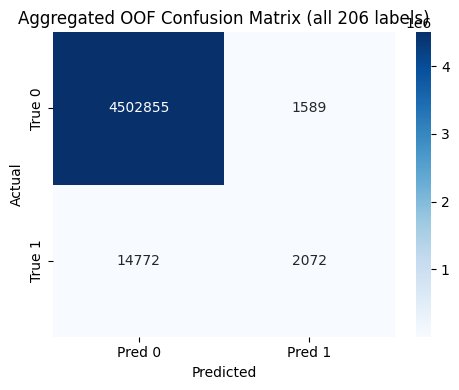

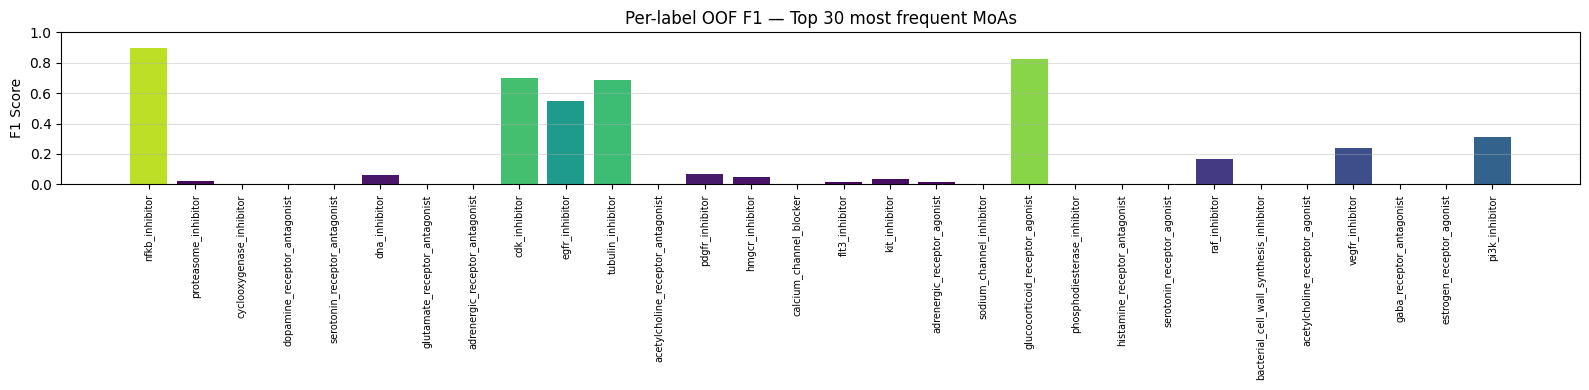

In [31]:
# Aggregated confusion matrix (all 206 labels flattened)
cm = confusion_matrix(oof_targets.ravel(), oof_pred_labels.ravel())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
ax.set_title('Aggregated OOF Confusion Matrix (all 206 labels)')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

# Per-label F1 for top-30 most frequent MoAs
label_counts = oof_targets.sum(axis=0)
top_n        = 30
top_idx      = np.argsort(label_counts)[::-1][:top_n]
per_label_f1 = f1_score(oof_targets[:, top_idx], oof_pred_labels[:, top_idx],
                         average=None, zero_division=0)
label_names  = main_targets_df.columns[top_idx]

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(range(top_n), per_label_f1, color=plt.cm.viridis(per_label_f1))
ax.set_xticks(range(top_n))
ax.set_xticklabels(label_names, rotation=90, fontsize=7)
ax.set_title(f'Per-label OOF F1 — Top {top_n} most frequent MoAs')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## Competition Metric — Mean Column-wise Log Loss

F1 and accuracy are useful diagnostic tools, but the actual competition score is the **mean column-wise log loss** across all 206 targets (lower is better). This is computed on the OOF predictions already collected above — no retraining needed.

In [32]:
def moa_log_loss(y_true, y_pred):
    """Mean column-wise log loss — the actual competition metric."""
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return np.mean([log_loss(y_true[:, j], y_pred[:, j], labels=[0, 1])
                    for j in range(y_true.shape[1])])

# Per-fold log loss (recover fold assignment from main_dataset)
fold_assignments = main_dataset['fold'].values
fold_log_losses  = []
for fold_id in range(N_FOLDS):
    mask = fold_assignments == fold_id
    fold_ll = moa_log_loss(oof_targets[mask], oof_preds[mask])
    fold_log_losses.append(fold_ll)
    print(f"  Fold {fold_id}: {fold_ll:.5f}")

mean_ll = np.mean(fold_log_losses)
std_ll  = np.std(fold_log_losses)
print(f"\nOOF Mean Column-wise Log Loss : {mean_ll:.5f} ± {std_ll:.5f}")

# Reference baselines
pos_rate_per_col  = oof_targets.mean(axis=0)
baseline_mean_ll  = moa_log_loss(oof_targets,
                                  np.tile(pos_rate_per_col, (len(oof_targets), 1)))
baseline_half_ll  = moa_log_loss(oof_targets,
                                  np.full_like(oof_preds, 0.5))

print(f"\n--- Reference baselines ---")
print(f"  Predict 0.5 for everything    : {baseline_half_ll:.5f}  (pure ignorance)")
print(f"  Predict column mean pos rate  : {baseline_mean_ll:.5f}  (trivial baseline)")
print(f"  Kaggle top leaderboard        : ~0.01300")
print(f"  Exp1 (this model)             : {mean_ll:.5f}")
print(f"  Exp2 target (after training)  : ~0.01500–0.01800")

  Fold 0: 0.01994
  Fold 1: 0.01882
  Fold 2: 0.02123
  Fold 3: 0.01871
  Fold 4: 0.02125

OOF Mean Column-wise Log Loss : 0.01999 ± 0.00111

--- Reference baselines ---
  Predict 0.5 for everything    : 0.69315  (pure ignorance)
  Predict column mean pos rate  : 0.02220  (trivial baseline)
  Kaggle top leaderboard        : ~0.01300
  Exp1 (this model)             : 0.01999
  Exp2 target (after training)  : ~0.01500–0.01800


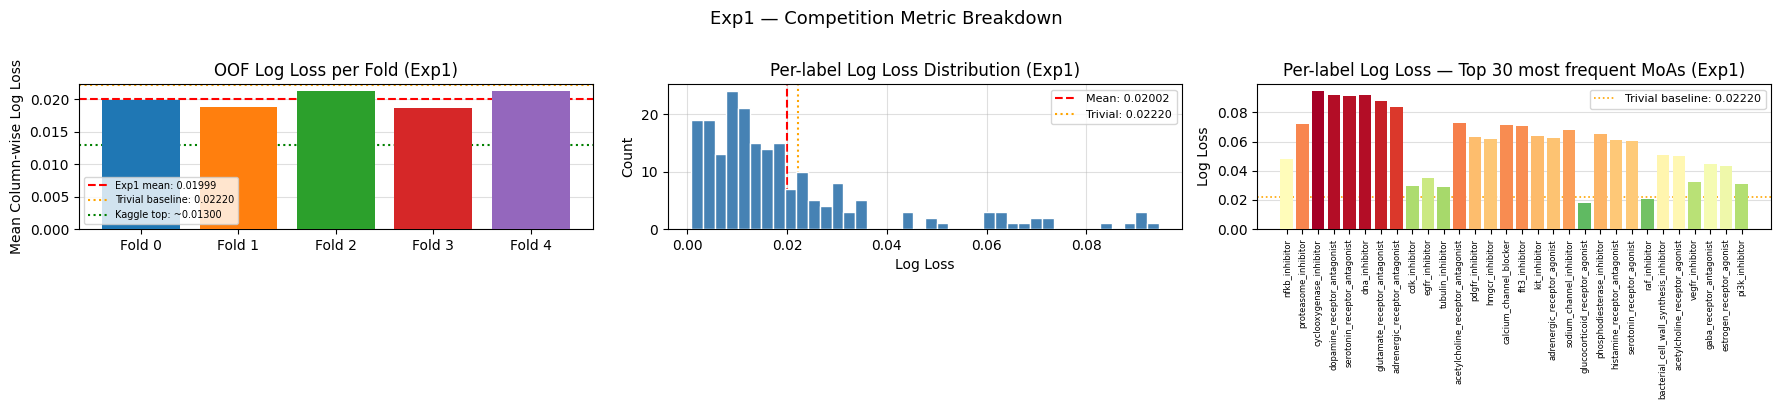


Metric                                         Exp1
----------------------------------------------------
OOF Mean Col-wise Log Loss                  0.01999
OOF Log Loss std across folds               0.00111
Trivial baseline (predict col mean)         0.02220
Predict 0.5 everywhere                      0.69315
Kaggle leaderboard top                     ~0.01300
OOF Macro F1                                 0.0510
OOF Accuracy (flat)                          0.9964


In [33]:
colors     = plt.cm.tab10.colors
fold_labels = [f"Fold {i}" for i in range(N_FOLDS)]

# Per-label log loss
per_label_ll = np.array([
    log_loss(oof_targets[:, j], np.clip(oof_preds[:, j], 1e-15, 1 - 1e-15), labels=[0, 1])
    for j in range(OUTPUT_DIM)
])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# --- Plot 1: per-fold log loss with baselines ---
bars = axes[0].bar(fold_labels, fold_log_losses, color=colors[:N_FOLDS], zorder=3)
axes[0].axhline(mean_ll,           color='red',    linestyle='--', linewidth=1.5, label=f'Exp1 mean: {mean_ll:.5f}')
axes[0].axhline(baseline_mean_ll,  color='orange', linestyle=':',  linewidth=1.5, label=f'Trivial baseline: {baseline_mean_ll:.5f}')
axes[0].axhline(0.013,             color='green',  linestyle=':',  linewidth=1.5, label='Kaggle top: ~0.01300')
axes[0].set_title('OOF Log Loss per Fold (Exp1)')
axes[0].set_ylabel('Mean Column-wise Log Loss')
axes[0].legend(fontsize=7)
axes[0].grid(axis='y', alpha=0.4, zorder=0)

# --- Plot 2: distribution of per-label log loss ---
axes[1].hist(per_label_ll, bins=40, color='steelblue', edgecolor='white', zorder=3)
axes[1].axvline(np.mean(per_label_ll), color='red', linestyle='--',
                label=f'Mean: {np.mean(per_label_ll):.5f}')
axes[1].axvline(baseline_mean_ll, color='orange', linestyle=':',
                label=f'Trivial: {baseline_mean_ll:.5f}')
axes[1].set_title('Per-label Log Loss Distribution (Exp1)')
axes[1].set_xlabel('Log Loss')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4, zorder=0)

# --- Plot 3: per-label log loss for top-30 most frequent MoAs ---
label_counts = oof_targets.sum(axis=0)
top_n  = 30
top_idx = np.argsort(label_counts)[::-1][:top_n]
top_ll  = per_label_ll[top_idx]
top_names = main_targets_df.columns[top_idx]

bar_colors = plt.cm.RdYlGn_r(top_ll / top_ll.max())
axes[2].bar(range(top_n), top_ll, color=bar_colors, zorder=3)
axes[2].axhline(baseline_mean_ll, color='orange', linestyle=':', linewidth=1.2,
                label=f'Trivial baseline: {baseline_mean_ll:.5f}')
axes[2].set_xticks(range(top_n))
axes[2].set_xticklabels(top_names, rotation=90, fontsize=6)
axes[2].set_title(f'Per-label Log Loss — Top {top_n} most frequent MoAs (Exp1)')
axes[2].set_ylabel('Log Loss')
axes[2].legend(fontsize=8)
axes[2].grid(axis='y', alpha=0.4, zorder=0)

plt.suptitle('Exp1 — Competition Metric Breakdown', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'Metric':<40} {'Exp1':>10}")
print('-' * 52)
print(f"{'OOF Mean Col-wise Log Loss':<40} {mean_ll:>10.5f}")
print(f"{'OOF Log Loss std across folds':<40} {std_ll:>10.5f}")
print(f"{'Trivial baseline (predict col mean)':<40} {baseline_mean_ll:>10.5f}")
print(f"{'Predict 0.5 everywhere':<40} {baseline_half_ll:>10.5f}")
print(f"{'Kaggle leaderboard top':<40} {'~0.01300':>10}")
print(f"{'OOF Macro F1':<40} {oof_f1:>10.4f}")
print(f"{'OOF Accuracy (flat)':<40} {oof_acc:>10.4f}")